In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, davies_bouldin_score, calinski_harabasz_score

import time
import psutil
import threading
from memory_profiler import memory_usage

# functions

In [18]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

# loading processed dataset

In [2]:
with open('preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [3]:
dataset_folder = 'dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'dataset_processed.parquet'))
df = df.drop(columns=config['columns_to_drop'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787102 entries, 0 to 787101
Data columns (total 76 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Destination Port               787102 non-null  int64  
 1   Flow Duration                  787102 non-null  int64  
 2   Total Fwd Packets              787102 non-null  int64  
 3   Total Backward Packets         787102 non-null  int64  
 4   Total Length of Bwd Packets    787102 non-null  int64  
 5   Fwd Packet Length Max          787102 non-null  int64  
 6   Fwd Packet Length Min          787102 non-null  int64  
 7   Fwd Packet Length Std          787102 non-null  float64
 8   Bwd Packet Length Max          787102 non-null  int64  
 9   Bwd Packet Length Min          787102 non-null  int64  
 10  Bwd Packet Length Std          787102 non-null  float64
 11  Flow Bytes/s                   787102 non-null  float64
 12  Flow Packets/s                

# splitting dataset

In [5]:
# data to be used will be one with benign/false anomalies

# Preparing features and truth labels
X = df.drop(['Label','anomaly',], axis=1)
y = df['anomaly']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train = X_train[y_train == 0]
y_train = y_train[y_train == 0]

# scaling dataset

In [6]:
# Initializing StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test and validation set using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# AutoEncoder Iteration 1

## defining autoencoder architecture

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_autoencoder(input_dim: int, bottleneck: int = 8,
                      dropout_rate: float = 0.2, l2_reg: float = 1e-4):
    inputs = Input(shape=(input_dim,))

    # Encoder
    x = Dense(128, kernel_regularizer=l2(l2_reg))(inputs)  # wider first layer
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(32, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(16, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    # Bottleneck — increased from 4 to 8
    bottleneck_layer = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder — mirror of encoder
    x = Dense(16, kernel_regularizer=l2(l2_reg))(bottleneck_layer)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(32, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    outputs = Dense(input_dim, activation='linear', name='reconstruction')(x)
    model = Model(inputs, outputs, name='autoencoder')
    return model


# Build & compile
tf.keras.backend.clear_session()
model = build_autoencoder(input_dim=X.shape[1], dropout_rate=0.3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 74)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32)             │             

 Total params: 43,186 (168.70 KB)

 Trainable params: 42,226 (164.95 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_autoencoder(input_dim: int, bottleneck: int = 8,
                      dropout_rate: float = 0.2,):
    inputs = Input(shape=(input_dim,))

    # Encoder
    # x = Dense(128)(inputs)  # wider first layer
    # x = BatchNormalization()(x)
    # x = tf.keras.activations.relu(x)
    # x = Dropout(dropout_rate)(x)

    x = Dense(64)(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(32)(x)
    # x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(16)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    # Bottleneck — increased from 4 to 8
    bottleneck_layer = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder — mirror of encoder
    x = Dense(16)(bottleneck_layer)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(32)(x)
    # x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    # x = Dense(128)(x)
    # x = BatchNormalization()(x)
    # x = tf.keras.activations.relu(x)

    outputs = Dense(input_dim, activation='linear', name='reconstruction')(x)
    model = Model(inputs, outputs, name='autoencoder')
    return model


# Build & compile
tf.keras.backend.clear_session()
model = build_autoencoder(input_dim=74, dropout_rate=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

model.summary()

Epoch 1/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.6827 - mae: 0.2748 - val_loss: 0.4396 - val_mae: 0.1743 - learning_rate: 0.0010
Epoch 2/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.5018 - mae: 0.2101 - val_loss: 0.3299 - val_mae: 0.1600 - learning_rate: 0.0010
Epoch 3/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.4372 - mae: 0.1995 - val_loss: 0.3675 - val_mae: 0.1506 - learning_rate: 0.0010
Epoch 4/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.4101 - mae: 0.1922 - val_loss: 0.2806 - val_mae: 0.1380 - learning_rate: 0.0010
Epoch 5/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.3905 - mae: 0.1878 - val_loss: 0.3013 - val_mae: 0.1426 - learning_rate: 0.0010
Epoch 6/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.3789 - mae: 0.1852 - val_loss: 0.2565 - val_mae: 0.1354 - learning_rate: 0.0010
Epoch 7/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.3684 - mae: 0.1841 - val_loss: 0.2608 - val_mae: 0.1441 - learning_r

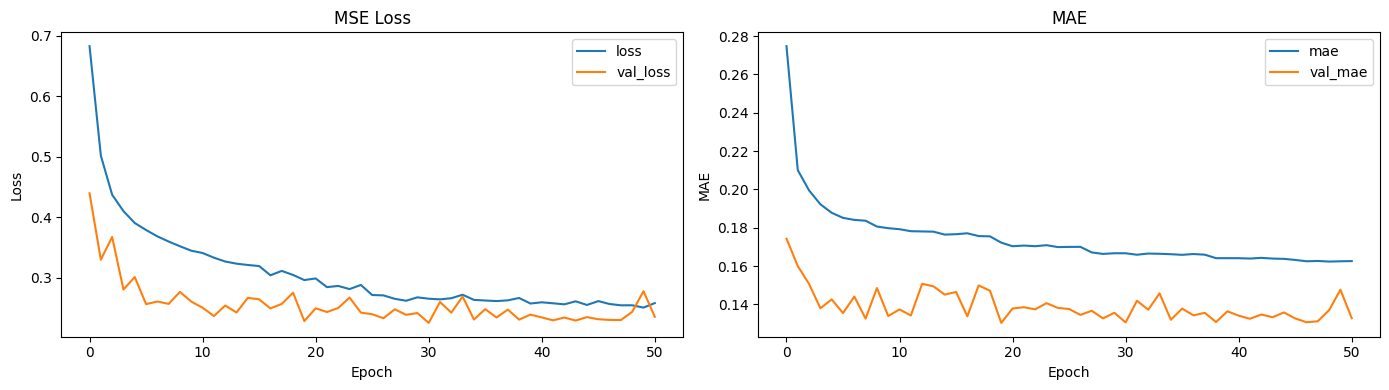

Best val_loss:  0.225529 at epoch 30
Final val_loss: 0.235646
Stopped at epoch: 51


In [10]:
# split the train dataset to have validation dataset
X_train_final, X_val = train_test_split(
    X_train_scaled, test_size=0.2, random_state=42, shuffle=True
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=1e-6,
    patience=20,
    verbose=1,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train_final, X_train_final,
    validation_data=(X_val, X_val),
    batch_size=512,
    epochs=300,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ── Better plotting ───────────────────────────────────────
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
hist_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# MAE
hist_df[['mae', 'val_mae']].plot(ax=axes[1])
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

# ── Sanity checks ─────────────────────────────────────────
print(f"Best val_loss:  {hist_df['val_loss'].min():.6f} at epoch {hist_df['val_loss'].idxmin()}")
print(f"Final val_loss: {hist_df['val_loss'].iloc[-1]:.6f}")
print(f"Stopped at epoch: {len(hist_df)}")

## validation of train-val results

In [12]:
# After training, run this to evaluate
train_recon = model.predict(X_train_final, batch_size=512)
val_recon   = model.predict(X_val, batch_size=512)

train_mse = np.mean(np.square(X_train_final - train_recon))
val_mse   = np.mean(np.square(X_val - val_recon))

print(f"Train MSE: {train_mse:.4f}")   # target: < 0.15
print(f"Val MSE:   {val_mse:.4f}")     # target: < 0.15
print(f"Gap:       {abs(val_mse - train_mse):.4f}")  # target: < 0.05

709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train MSE: 0.2590
Val MSE:   0.2126
Gap:       0.0464


## save model to reduce headache

In [11]:
model.save('ann4-nice.keras')

## testing model performance

### feature analysis

In [15]:
train_recon = model.predict(X_train_final, batch_size=512)
errors_per_feature = np.mean(np.square(X_train_final - train_recon), axis=0)
feature_errors = pd.Series(errors_per_feature, index=X.columns).sort_values(ascending=False)

print("Top 10 worst reconstructed features:")
print(feature_errors.head(10))
print("\nBottom 10 best reconstructed features:")
print(feature_errors.tail(10))

709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Top 10 worst reconstructed features:
Fwd Header Length              1.239102
min_seg_size_forward           1.212342
Subflow Fwd Bytes              1.172421
Fwd URG Flags                  0.931663
act_data_pkt_fwd               0.778765
Bwd Header Length              0.692581
Total Length of Bwd Packets    0.663490
iat_variability                0.659204
Total Backward Packets         0.645223
Total Fwd Packets              0.643522
dtype: float64

Bottom 10 best reconstructed features:
Avg Fwd Segment Size     0.093479
Flow IAT Min             0.086922
Flow Packets/s_log       0.086846
Bwd IAT Total            0.078152
Fwd Packet Length Min    0.073934
FIN Flag Count           0.073272
Flow Duration_log        0.064282
Fwd IAT Total            0.060600
ack_ratio                0.058991
Flow Duration            0.054454
dtype: float64


### Error Analysis

709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


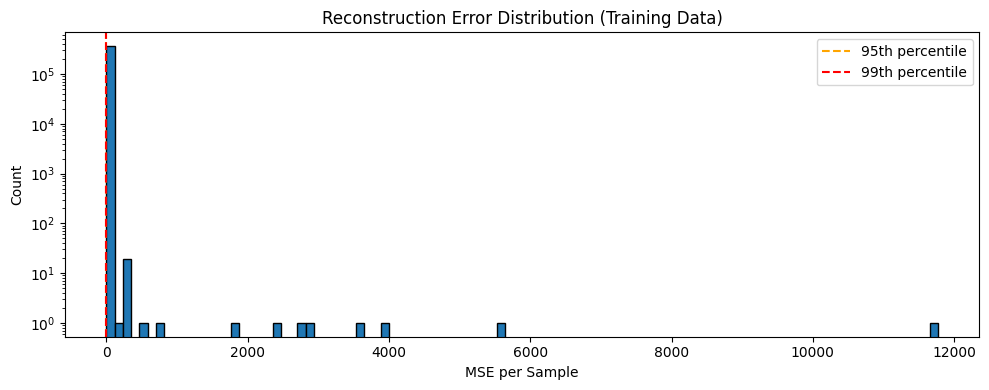

Percentile  90.0: 0.2601
Percentile  95.0: 0.5714
Percentile  99.0: 1.8232
Percentile  99.5: 2.3963


In [16]:
# ── 1. Compute reconstruction error on NORMAL training data ──
train_recon = model.predict(X_train_final, batch_size=512)
train_errors = np.mean(np.square(X_train_final - train_recon), axis=1)
# shape: (385482,) — one error score per sample
# ── 2. Visualize the error distribution ──

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=100, edgecolor='black', log=True)
plt.title('Reconstruction Error Distribution (Training Data)')
plt.xlabel('MSE per Sample')
plt.ylabel('Count')
plt.axvline(np.percentile(train_errors, 95), color='orange', linestyle='--', label='95th percentile')
plt.axvline(np.percentile(train_errors, 99), color='red',    linestyle='--', label='99th percentile')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Check percentile values ──
for p in [90, 95, 99, 99.5]:
    print(f"Percentile {p:5.1f}: {np.percentile(train_errors, p):.4f}")

In [21]:
# ── 5. Score your test data ──
test_recon  = model.predict(X_test_scaled, batch_size=512)
test_errors = np.mean(np.square(X_test_scaled - test_recon), axis=1)

Anomaly threshold: 1.8232
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Total test samples:  236131
Anomalies detected:  20602 (8.72%)


### ROC and PR Curves

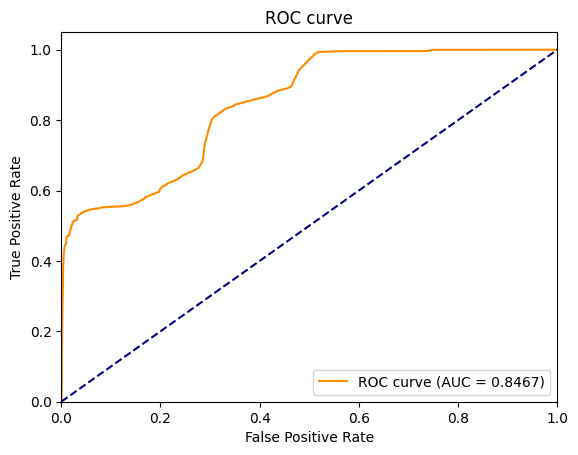

Best threshold:  1.097174279820258
Best F1-Score:  0.6309196137651942


C:\Users\Nathaniel\AppData\Local\Temp\ipykernel_15112\3851632075.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * recall * precision / (recall + precision)


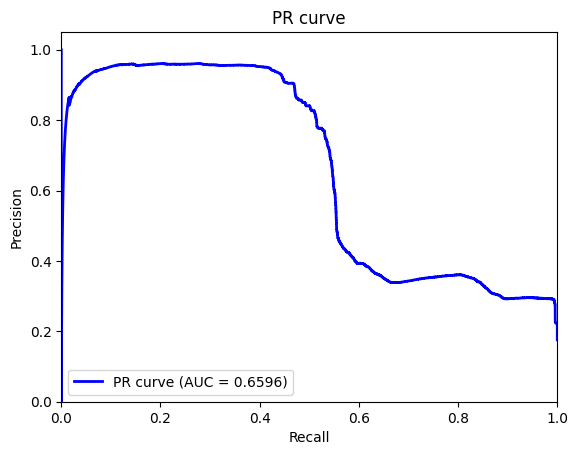

In [22]:
actual_anomaly = y_test

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    test_errors)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    test_errors)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

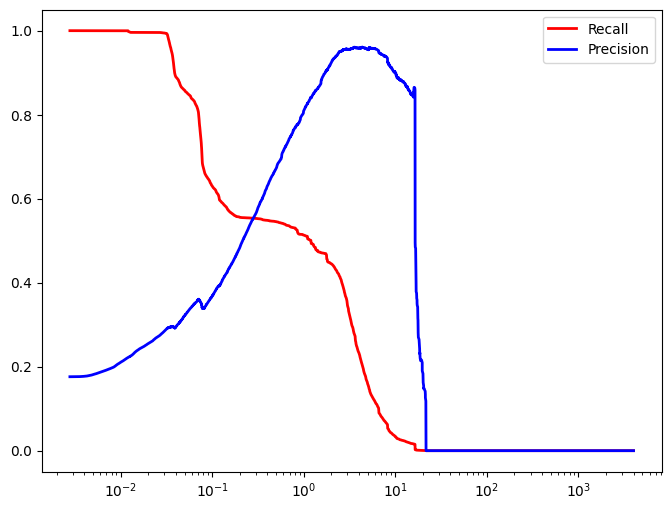

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.xscale('log')
plt.legend()

### finding threshold and classification of anomalies

In [26]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test, test_errors)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (test_errors >= optimal_threshold).astype(int)

Optimal Threshold: 1.097174279820258


### Classification Report

In [27]:
from sklearn.metrics import classification_report

# target_names allows you to label the output for better readability
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94    194558
     Anomaly       0.83      0.51      0.63     41573

    accuracy                           0.89    236131
   macro avg       0.87      0.74      0.78    236131
weighted avg       0.89      0.89      0.88    236131



### Confusion Matrix

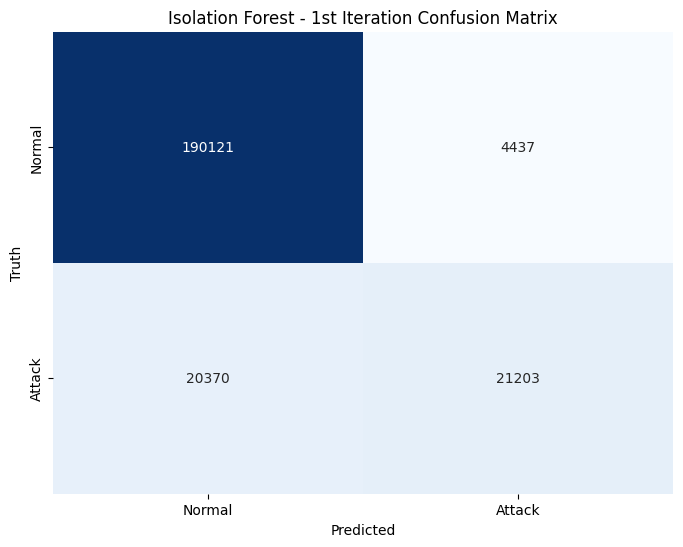

In [28]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 1st Iteration Confusion Matrix')
plt.show()

# AutoEncoder Iteration 2

## defining autoencoder architecture

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_autoencoder(input_dim: int, bottleneck: int = 8,
                      dropout_rate: float = 0.2,):
    inputs = Input(shape=(input_dim,))

    # Encoder
    x = Dense(64)(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(32)(x)
    # x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(16)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    # Bottleneck — increased from 4 to 8
    bottleneck_layer = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder — mirror of encoder
    x = Dense(16)(bottleneck_layer)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = Dense(32)(x)
    # x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(dropout_rate)(x)


    outputs = Dense(input_dim, activation='linear', name='reconstruction')(x)
    model = Model(inputs, outputs, name='autoencoder')
    return model


# Build & compile
tf.keras.backend.clear_session()
model = build_autoencoder(input_dim=74, dropout_rate=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 74)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 74)             │         4,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,794 (61.70 KB)

 Trainable params: 15,474 (60.45 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.5526 - mae: 0.2675 - val_loss: 0.3103 - val_mae: 0.1673 - learning_rate: 0.0010
Epoch 2/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.3708 - mae: 0.2047 - val_loss: 0.2181 - val_mae: 0.1357 - learning_rate: 0.0010
Epoch 3/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.3325 - mae: 0.1949 - val_loss: 0.1942 - val_mae: 0.1340 - learning_rate: 0.0010
Epoch 4/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.3083 - mae: 0.1891 - val_loss: 0.1690 - val_mae: 0.1216 - learning_rate: 0.0010
Epoch 5/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2949 - mae: 0.1839 - val_loss: 0.1607 - val_mae: 0.1218 - learning_rate: 0.0010
Epoch 6/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2864 - mae: 0.1806 - val_loss: 0.1478 - val_mae: 0.1154 - learning_rate: 0.0010
Epoch 7/300
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2796 - mae: 0.1767 - val_loss: 0.1405 - val_mae: 0.1150 - learning_rate: 0.001

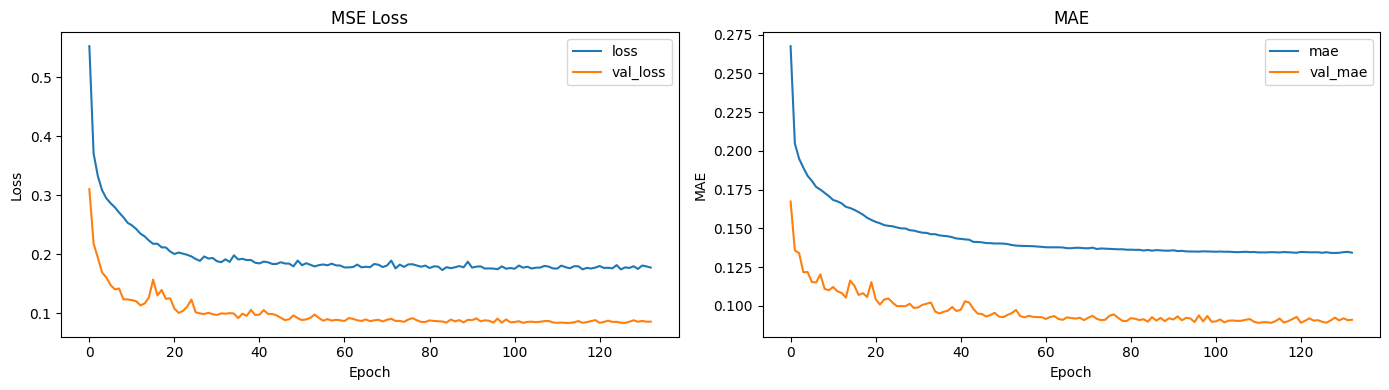

Best val_loss:  0.083694 at epoch 112
Final val_loss: 0.085806
Stopped at epoch: 133


In [31]:
# split the train dataset to have validation dataset
X_train_final, X_val = train_test_split(
    X_train_scaled, test_size=0.2, random_state=42, shuffle=True
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=1e-6,
    patience=20,
    verbose=1,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train_final, X_train_final,
    validation_data=(X_val, X_val),
    batch_size=512,
    epochs=300,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ── Better plotting ───────────────────────────────────────
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
hist_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# MAE
hist_df[['mae', 'val_mae']].plot(ax=axes[1])
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

# ── Sanity checks ─────────────────────────────────────────
print(f"Best val_loss:  {hist_df['val_loss'].min():.6f} at epoch {hist_df['val_loss'].idxmin()}")
print(f"Final val_loss: {hist_df['val_loss'].iloc[-1]:.6f}")
print(f"Stopped at epoch: {len(hist_df)}")

## validation of train-val results

In [32]:
# After training, run this to evaluate
train_recon = model.predict(X_train_final, batch_size=512)
val_recon   = model.predict(X_val, batch_size=512)

train_mse = np.mean(np.square(X_train_final - train_recon))
val_mse   = np.mean(np.square(X_val - val_recon))

print(f"Train MSE: {train_mse:.4f}")   # target: < 0.15
print(f"Val MSE:   {val_mse:.4f}")     # target: < 0.15
print(f"Gap:       {abs(val_mse - train_mse):.4f}")  # target: < 0.05

709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train MSE: 0.1117
Val MSE:   0.0837
Gap:       0.0280


## save model to reduce headache

In [41]:
model.save('ann-iter2.keras')

## testing model performance

### feature analysis

In [33]:
train_recon = model.predict(X_train_final, batch_size=512)
errors_per_feature = np.mean(np.square(X_train_final - train_recon), axis=0)
feature_errors = pd.Series(errors_per_feature, index=X.columns).sort_values(ascending=False)

print("Top 10 worst reconstructed features:")
print(feature_errors.head(10))
print("\nBottom 10 best reconstructed features:")
print(feature_errors.tail(10))

709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Top 10 worst reconstructed features:
Fwd Header Length                1.182804
min_seg_size_forward             1.153656
Subflow Fwd Bytes                1.056401
Bwd Header Length                0.670116
Down/Up Ratio                    0.263482
Init_Win_bytes_forward           0.225494
iat_variability                  0.204231
Destination Port                 0.130763
Destination Port Distribution    0.122569
act_data_pkt_fwd                 0.112171
dtype: float64

Bottom 10 best reconstructed features:
Packet Length Std     0.026809
Flow Duration         0.026555
FIN Flag Count        0.025244
Flow Bytes/s          0.024187
payload_efficiency    0.023895
packet_density        0.022709
Flow Packets/s        0.022709
ECE Flag Count        0.019045
RST Flag Count        0.018989
Fwd Packets/s         0.018243
dtype: float64


### Error Analysis

709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


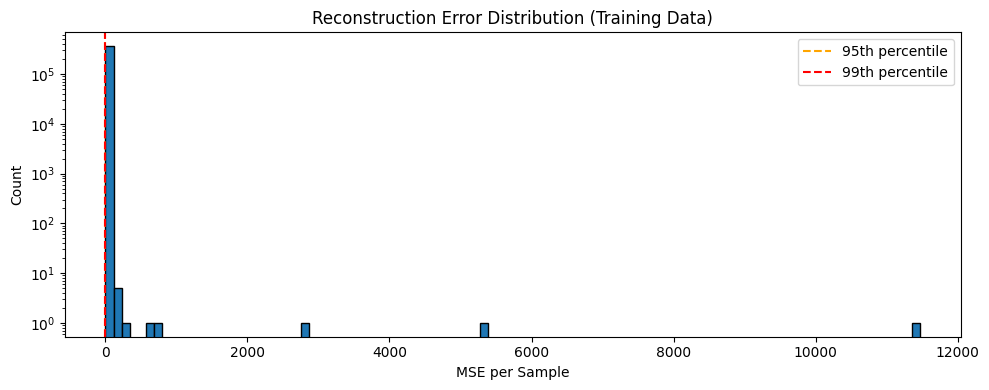

Percentile  90.0: 0.1050
Percentile  95.0: 0.1814
Percentile  99.0: 0.5199
Percentile  99.5: 0.7593


In [34]:
# ── 1. Compute reconstruction error on NORMAL training data ──
train_recon = model.predict(X_train_final, batch_size=512)
train_errors = np.mean(np.square(X_train_final - train_recon), axis=1)
# shape: (385482,) — one error score per sample
# ── 2. Visualize the error distribution ──

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=100, edgecolor='black', log=True)
plt.title('Reconstruction Error Distribution (Training Data)')
plt.xlabel('MSE per Sample')
plt.ylabel('Count')
plt.axvline(np.percentile(train_errors, 95), color='orange', linestyle='--', label='95th percentile')
plt.axvline(np.percentile(train_errors, 99), color='red',    linestyle='--', label='99th percentile')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Check percentile values ──
for p in [90, 95, 99, 99.5]:
    print(f"Percentile {p:5.1f}: {np.percentile(train_errors, p):.4f}")

In [35]:
# ── 5. Score your test data ──
test_recon  = model.predict(X_test_scaled, batch_size=512)
test_errors = np.mean(np.square(X_test_scaled - test_recon), axis=1)

462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


### ROC and PR Curves

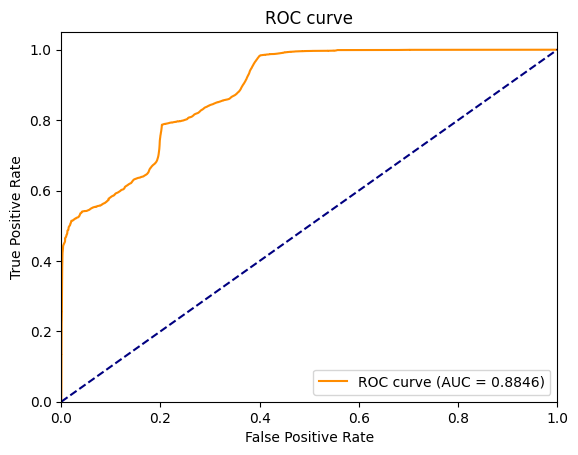

C:\Users\Nathaniel\AppData\Local\Temp\ipykernel_15112\3851632075.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * recall * precision / (recall + precision)


Best threshold:  0.35146333509295796
Best F1-Score:  0.6388830757272266


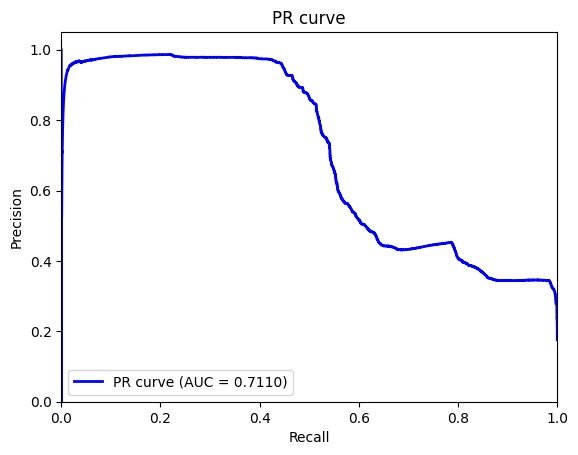

In [36]:
actual_anomaly = y_test

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    test_errors)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    test_errors)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

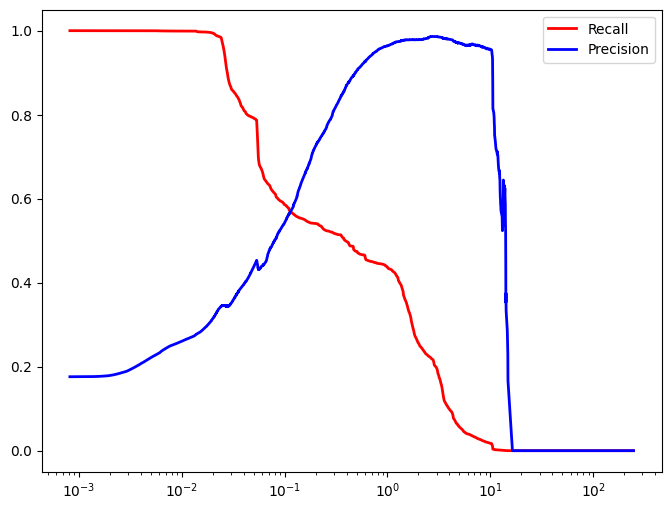

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.xscale('log')
plt.legend()

### finding threshold and classification of anomalies

In [38]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test, test_errors)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (test_errors >= optimal_threshold).astype(int)

Optimal Threshold: 0.35146333509295796


### Classification Report

In [39]:
from sklearn.metrics import classification_report

# target_names allows you to label the output for better readability
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94    194558
     Anomaly       0.84      0.51      0.64     41573

    accuracy                           0.90    236131
   macro avg       0.87      0.75      0.79    236131
weighted avg       0.89      0.90      0.89    236131



### Confusion Matrix

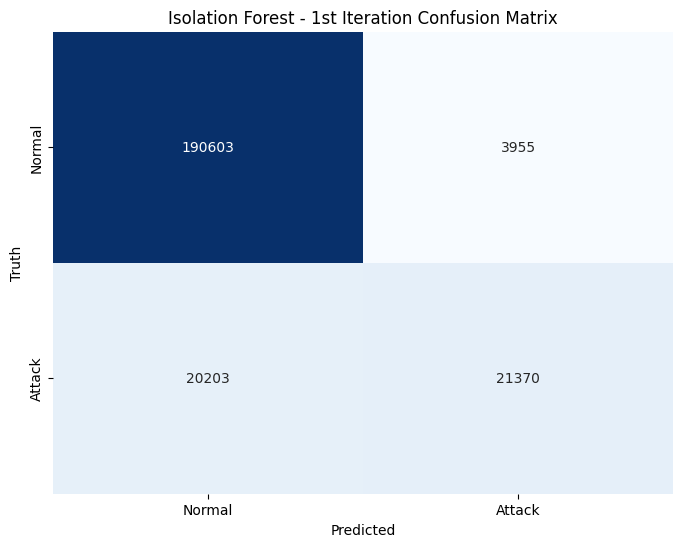

In [40]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 1st Iteration Confusion Matrix')
plt.show()